## **Machine Learning Modelling**

The goal of this section is to develop machine learning models to predict customer churn, evaluate their performance using appropriate metrics, and optimize them to improve churn detection. Additionally, this section aims to identify the key factors driving customer churn, providing insights that can support data-driven business decisions and targeted retention strategies.

<br>

#### **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Save models
import pickle

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Ferdinand Taslim\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


<br>

#### **2. Load Data**

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 24)
Test shape: (1409, 24)


<br>

#### **3. Logistic Regression Model**

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression is sensitive to feature magnitude. Scaling ensures all features contribute equally.

In [4]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Training helps model learns relationship between features and churn probability. max_iter=1000 ensures convergence.

<br>

#### **4. Predict using Logistic Regression Model**

In [5]:
y_pred_log = log_model.predict(X_test_scaled)

<br>

#### **5. Evaluate Logistic Regression**

In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8026969481902059

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



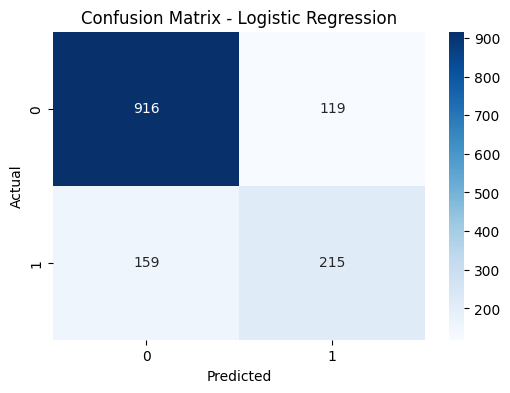

In [7]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The baseline Logistic Regression model performs well overall, achieving strong accuracy and a balanced precision-recall trade-off. However, it misses a significant portion of churners (~43%), which limits its effectiveness for retention strategies.

<br>

#### **6. Random Forest Model**

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Random Forest model captures non-linear relationships and handles complex interactions.

<br>

#### **7. Predict using Random Forest Model**

In [9]:
y_pred_rf = rf_model.predict(X_test)

<br>

#### **8. Evaluate Random Forest Model**

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7955997161107168

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Random Forest performs similarly in accuracy but has lower recall for churners, making it less effective at identifying at-risk customers. While it performs slightly better in identifying non-churners, this is less valuable for the business objective.

<br>

#### **9. Optimize Models**

In [11]:
log_model_optimized = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model_optimized.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [12]:
y_probs = log_model_optimized.predict_proba(X_test_scaled)[:, 1]
y_pred_custom = (y_probs > 0.3).astype(int)

In [13]:
rf_model_optimized = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model_optimized.fit(X_train, y_train)

y_pred_rf_optimized = rf_model_optimized.predict(X_test)

<br>

#### **10. Evaluate Optimized Model**

In [14]:
print("Logistic Regression (Optimized)")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

Logistic Regression (Optimized)
Accuracy: 0.6643009226401704
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1035
           1       0.44      0.91      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.66      0.68      1409



The optimized Logistic Regression significantly improves recall, capturing most churners. However, this comes at the cost of very low precision and accuracy, resulting in a high number of false positives. This would lead to inefficient resource allocation in a real business setting.

In [15]:
print("\nRandom Forest (Optimized)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_optimized))
print(classification_report(y_test, y_pred_rf_optimized))


Random Forest (Optimized)
Accuracy: 0.7750177430801988
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.73      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



The optimized Random Forest achieves a strong balance between recall and precision. It significantly improves churn detection compared to baseline models while maintaining acceptable accuracy and reducing false positives compared to the aggressively optimized Logistic Regression.

The **Optimized Random Forest model** was selected as the final model due to its ability to achieve a strong balance between predictive performance and business practicality. It delivers a recall of 73% for churn prediction while maintaining a precision of 56%, ensuring that a substantial proportion of churners are correctly identified without generating excessive false positives. Additionally, the model maintains a relatively high overall accuracy of 77.5%, indicating solid general performance.

From a business perspective, this balance is critical. The model is capable of identifying the majority of at-risk customers, enabling more effective and timely retention strategies, while avoiding unnecessary targeting of customers who are unlikely to churn. This results in more efficient use of resources and minimizes operational costs associated with false alarms. Overall, the Optimized Random Forest provides a practical and scalable solution that aligns well with real-world business objectives by maximizing customer retention impact while maintaining operational efficiency.

<br>

#### **11. Save Models**

In [16]:
with open("../models/log_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

with open("../models/rf_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("../models/log_model_optimized.pkl", "wb") as f:
    pickle.dump(log_model_optimized, f)

with open("../models/rf_model_optimized.pkl", "wb") as f:
    pickle.dump(rf_model_optimized, f)

<br>

#### **12. Feature Importance**

In [17]:
# Get coefficients
importances = log_model_optimized.coef_[0]

# Get feature names
features = X_train.columns

# Create dataframe
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by absolute importance
feat_df['Abs Importance'] = feat_df['Importance'].abs()
feat_df = feat_df.sort_values(by='Abs Importance', ascending=False)

feat_df.head(10)

,Feature,Importance,Abs Importance
3,Tenure Months,-1.189923,1.189923
2,Dependents,-0.691973,0.691973
13,Monthly Charges,-0.657114,0.657114
17,Internet Service_Fiber optic,0.614780,0.614780
20,Contract_Two year,-0.607623,0.607623
18,Internet Service_No,-0.532871,0.532871
14,Total Charges,0.483377,0.483377
19,Contract_One year,-0.321749,0.321749
11,Streaming Movies,0.218987,0.218987
10,Streaming TV,0.208571,0.208571


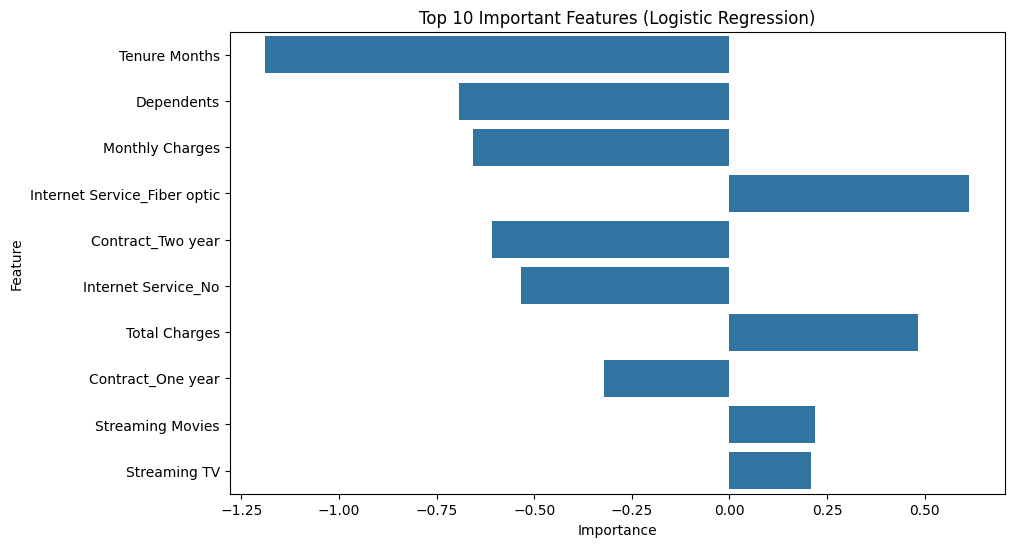

In [18]:
top_features = feat_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features)

plt.title("Top 10 Important Features (Logistic Regression)")
plt.show()

#### **Feature Importance Insights**
- Customer tenure is the strongest predictor of churn, with newer customers significantly more likely to leave  
- Long-term contracts (especially two-year) greatly reduce churn risk  
- Fiber optic users are more likely to churn, suggesting dissatisfaction with premium services  
- Customers without dependents show higher churn behavior  
- Higher total spending customers may still churn, indicating potential dissatisfaction despite value  

<br><br>

### **Summary**

Multiple machine learning models were developed to predict customer churn, including Logistic Regression and Random Forest. The baseline models achieved strong overall accuracy of around 80%, indicating good general performance in distinguishing between churn and non-churn customers. However, both models initially showed limitations in identifying churners, with relatively low recall scores for the churn class. This highlighted a common issue in imbalanced classification problems, where models tend to favor the majority class (non-churn customers).

To address this, model optimization techniques were applied, including class weighting and threshold adjustment. These improvements significantly increased the model’s ability to detect churners. While aggressive optimization (Logistic Regression with a lower threshold) achieved very high recall, it resulted in a substantial drop in precision and overall accuracy, leading to excessive false positives. In contrast, the optimized Random Forest model provided a more balanced performance, improving churn recall while maintaining reasonable precision and accuracy. As a result, it was selected as the final model due to its ability to effectively identify at-risk customers without overburdening business operations with false alarms.

Feature importance analysis further reinforced the findings from exploratory data analysis. Customer tenure emerged as the most influential factor, with longer-tenured customers significantly less likely to churn. Contract type also played a critical role, as customers on long-term contracts (especially two-year plans) showed much lower churn rates. Additionally, fiber optic internet users were more likely to churn, suggesting potential dissatisfaction with premium services. Other factors, such as having dependents and overall spending behavior, also contributed to churn patterns. These insights provide actionable guidance for businesses to design targeted retention strategies, particularly focusing on new customers, contract structures, and high-risk service segments.